In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==========================================
print("Pobieranie danych...")
steel_plates_faults = fetch_ucirepo(id=198)
X = steel_plates_faults.data.features
y_raw = steel_plates_faults.data.targets

Pobieranie danych...


In [2]:
# Konwersja one-hot na indeksy klas (0-6)
y = np.argmax(y_raw.values, axis=1)

# Podział na zbiór treningowy i testowy
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standaryzacja (kluczowa dla zbieżności sieci)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [3]:
# Konwersja na Tensory i przeniesienie na urządzenie (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

X_train_tensor = torch.tensor(X_train_scaled).float().to(device)
y_train_tensor = torch.tensor(y_train_raw).long().to(device)
X_test_tensor = torch.tensor(X_test_scaled).float().to(device)
y_test_tensor = torch.tensor(y_test_raw).long().to(device)

# DataLoader dla efektywnego treningu w paczkach (batchach)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

Używane urządzenie: cuda


In [11]:
# ==========================================
# 2. DEFINICJA ELASTYCZNEJ ARCHITEKTURY
# ==========================================
class SteelFaultNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim):
        super(SteelFaultNet, self).__init__()
        layers = []
        in_features = input_dim
        
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.BatchNorm1d(h)) # Stabilizacja treningu
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))   # Zapobieganie overfittingowi
            in_features = h
            
        layers.append(nn.Linear(in_features, output_dim))
        # Nie dodajemy Softmaxa, bo CrossEntropyLoss robi to za nas
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [12]:
# ==========================================
# 3. PĘTLA EKSPERYMENTALNA (GRID SEARCH)
# ==========================================
K1_vec = [16, 27, 32, 64, 128] # Neurony w 1. warstwie
K2_vec = [8, 16, 27, 32, 64]   # Neurony w 2. warstwie
results_matrix = np.zeros((len(K1_vec), len(K2_vec)))

best_acc = 0
best_config = ""

In [13]:
print("\nRozpoczynanie eksperymentów...")

for i, k1 in enumerate(K1_vec):
    for j, k2 in enumerate(K2_vec):
        # Inicjalizacja modelu dla danej pary (K1, K2)
        model = SteelFaultNet(input_dim=27, hidden_sizes=[k1, k2], output_dim=7).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        # Trening z prostym Early Stopping
        max_epochs = 50
        for epoch in range(max_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                outputs = model(x_batch)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
        
        # Ewaluacja na zbiorze testowym
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            _, predicted = torch.max(test_outputs, 1)
            accuracy = (predicted == y_test_tensor).float().mean().item() * 100
            
        results_matrix[i, j] = accuracy
        print(f"K1: {k1:3} | K2: {k2:3} | Accuracy: {accuracy:.2f}%")
        
        if accuracy > best_acc:
            best_acc = accuracy
            best_config = f"K1={k1}, K2={k2}"


Rozpoczynanie eksperymentów...
K1:  16 | K2:   8 | Accuracy: 70.44%
K1:  16 | K2:  16 | Accuracy: 72.49%
K1:  16 | K2:  27 | Accuracy: 73.78%
K1:  16 | K2:  32 | Accuracy: 73.78%
K1:  16 | K2:  64 | Accuracy: 74.55%
K1:  27 | K2:   8 | Accuracy: 71.98%
K1:  27 | K2:  16 | Accuracy: 73.78%
K1:  27 | K2:  27 | Accuracy: 74.81%
K1:  27 | K2:  32 | Accuracy: 74.81%
K1:  27 | K2:  64 | Accuracy: 76.09%
K1:  32 | K2:   8 | Accuracy: 73.01%
K1:  32 | K2:  16 | Accuracy: 76.35%
K1:  32 | K2:  27 | Accuracy: 74.55%
K1:  32 | K2:  32 | Accuracy: 76.86%
K1:  32 | K2:  64 | Accuracy: 77.89%
K1:  64 | K2:   8 | Accuracy: 76.61%
K1:  64 | K2:  16 | Accuracy: 78.15%
K1:  64 | K2:  27 | Accuracy: 75.58%
K1:  64 | K2:  32 | Accuracy: 75.58%
K1:  64 | K2:  64 | Accuracy: 77.12%
K1: 128 | K2:   8 | Accuracy: 76.86%
K1: 128 | K2:  16 | Accuracy: 75.32%
K1: 128 | K2:  27 | Accuracy: 78.15%
K1: 128 | K2:  32 | Accuracy: 77.12%
K1: 128 | K2:  64 | Accuracy: 77.38%


In [14]:
# ==========================================
# 4. WYNIKI I WIZUALIZACJA
# ==========================================
print("-" * 30)
print(f"NAJLEPSZY WYNIK: {best_acc:.2f}% dla konfiguracji {best_config}")

------------------------------
NAJLEPSZY WYNIK: 78.15% dla konfiguracji K1=64, K2=16


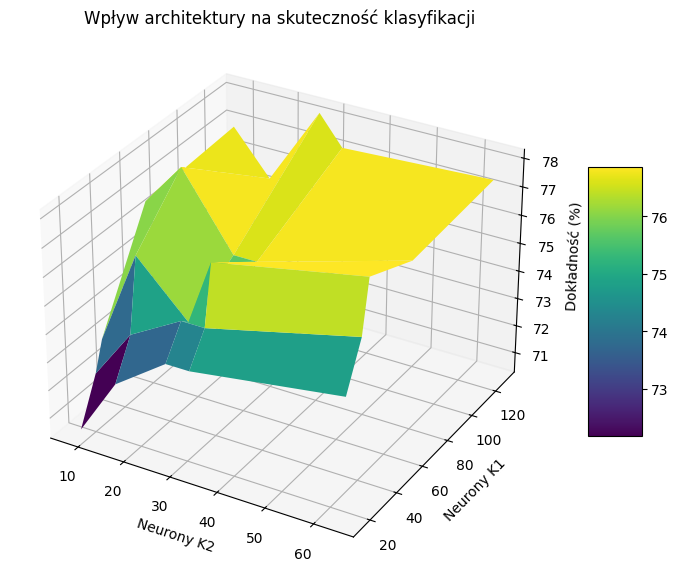

In [15]:
# Wykres 3D (walor edukacyjny z Kodu B)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
X_mesh, Y_mesh = np.meshgrid(K2_vec, K1_vec) # Uwaga na kolejność przy meshgrid

surf = ax.plot_surface(X_mesh, Y_mesh, results_matrix, cmap='viridis', edgecolor='none')
ax.set_xlabel('Neurony K2')
ax.set_ylabel('Neurony K1')
ax.set_zlabel('Dokładność (%)')
ax.set_title('Wpływ architektury na skuteczność klasyfikacji')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()